# v0.3.34 STDP LTP/LTD Network Adaptation Tutorial

This tutorial demonstrates STDP activity-dependent plasticity in a 100-neuron E-I spiking network, using package-level JAX-first simulations.

In [1]:
import jaxfne as jtfne
import numpy as np
import matplotlib.pyplot as plt

## 1. Network Geometry and Initial Weights

Place 100 neurons randomly inside a 3D unit sphere and build initial weights.

In [2]:
n_neurons = 100
pos, exc_mask, inh_mask = jtfne.build_stdp_network_geometry(n_neurons, seed=42)
W_init = jtfne.build_initial_stdp_weights(n_neurons, exc_mask, seed=42)

print(f"Positions shape: {pos.shape}")
print(f"Excitatory count: {int(np.sum(exc_mask))}")
print(f"Inhibitory count: {int(np.sum(inh_mask))}")

Positions shape: (100, 3)
Excitatory count: 70
Inhibitory count: 30


## 2. Triangular 6 Hz Stimulus Drive

Generate the 6 Hz triangular drive wave.

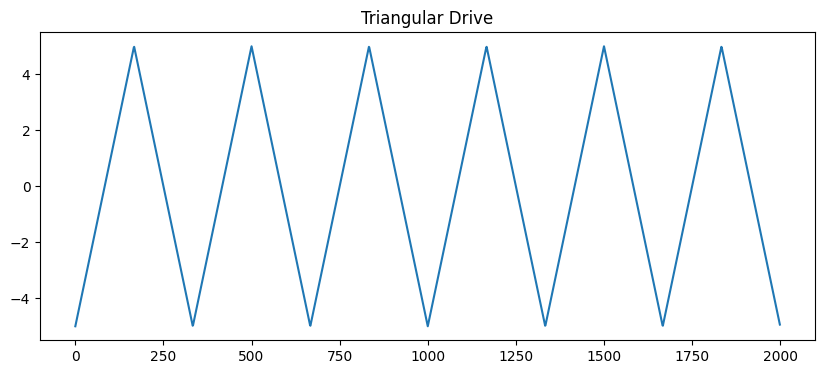

In [3]:
duration_ms = 1000.0
dt_ms = 0.5
stim = jtfne.generate_triangular_drive(duration_ms, dt_ms, freq_hz=6.0, amplitude=5.0)
plt.figure(figsize=(10, 4))
plt.plot(stim)
plt.title("Triangular Drive")
plt.show()

## 3. Plasticity Simulation Runner

Run a short chunk of simulation to demonstrate compilation and integration.

In [4]:
import jax.numpy as jnp
v = jnp.zeros(n_neurons) - 65.0
u = jnp.zeros(n_neurons)
s = jnp.zeros(n_neurons)
trace_pre = jnp.zeros(n_neurons)

stim_matrix = jnp.repeat(stim[:, None], n_neurons, axis=1)
noise = jnp.zeros_like(stim_matrix)

a = jnp.full(n_neurons, 0.02)
b = jnp.full(n_neurons, 0.2)
c = jnp.full(n_neurons, -65.0)
d = jnp.full(n_neurons, 8.0)

state_final, (vm_traj, spk_traj) = jtfne.run_stdp_simulation_chunk(
    v, u, s, trace_pre, W_init, stim_matrix, noise,
    a, b, c, d, exc_mask, inh_mask, dt_ms=dt_ms, plasticity_scale=0.1
)

print("Simulation successful!")
print(f"Final weights mean: {float(jnp.mean(state_final[4])):.4f}")

Simulation successful!
Final weights mean: 0.0213
